### Exercise  2.2
#### 📌 Question 2.2.1
##### Using the support vector machine function ksvm contained in the R package kernlab, find a good classifier for this data. Show the equation of your classifier, and how well it classifies the data points in the full data set.  (Don’t worry about test/validation data yet; we’ll cover that topic soon.)


In [124]:
library("kernlab")

# Load Data Shared with the credit card applications

path_data <- "/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/data 2.2/credit_card_data-headers.txt"

Data_1 <- read.table(path_data, sep = "\t", header = TRUE)


# Set up SVM model
    model <- ksvm(
  as.matrix(Data_1[, 0:10]),        # Variables  used for classification
  as.factor(Data_1[, 11]),         # Target variable
  type   = "C-svc",
  kernel = "vanilladot",
  C      = 100,
  scaled = TRUE
    )

# calculate a1…am
a <- colSums(model@xmatrix[[1]] * model@coef[[1]])
b <- -model@b

# Predict values
pred<- predict(model,Data_1[,1:10])

# Measure the accuracy

confusion_matrix <- table(pred, Data_1[,11])

confusion_matrix


Accuracy_val <- (confusion_matrix[[4]] + confusion_matrix[[1]])/nrow(Data_1)


print(paste("C value:", 100, " - Accuracy:", Accuracy_val))

 Setting default kernel parameters  


    
pred   0   1
   0 286  17
   1  72 279

[1] "C value: 100  - Accuracy: 0.863914373088685"


### `` Variating the C value to see how the accuracy change ``

### Answer Question 2.2.1

* Methodology performed
    - I have load the data in a table called Data_1 so that later can use the variables.
    - Set up the SVM model using the function ksvm, where I assign as preditors the columns 1 to 10 and target the column 11 that tells me that the application has been accepted or not. I also used as is requested Scaled= TRUE, C=100 and have selected vanilladot that is for linear equitions.
    - I get all the coefficient and the parameter B To build the Line Classifier.
    - Finally I perform a confusion matrix.
    - Measure the accuracy of Predictions.

## 📏 Classifier Equation

 -0.00100653481045754 $X_1$ + -0.00117290480606869 $X_2$ -0.00162619672181563 $X_3$ + 0.00300642026488163 $X_4$ +  1.00494056410557 $X_5$ + -0.00282594323050489 $X_6$ + 0.000260029506925719 $X_7$ + -0.000534955143592697 $X_8$ + -0.00122837582282642 $X_9$ + 0.106363399527215 $X_10$ + 0.0815849216596176 = 0 

### `` Where``

&nbsp;$X_1$ &rarr; A1 \
&nbsp;$X_2$ &rarr; A2 \
&nbsp;$X_3$ &rarr; A3 \
&nbsp;$X_4$ &rarr; A8 \
&nbsp;$X_5$ &rarr; A9 \
&nbsp;$X_6$ &rarr; A10 \
&nbsp;$X_7$ &rarr; A11 \
&nbsp;$X_8$ &rarr; A12 \
&nbsp;$X_9$ &rarr; A14 \
&nbsp;$X_10$ &rarr; A15

### with

#### `` C value: 100  - Accuracy: 0.863914373088685 ``


 Setting default kernel parameters  
[1] "C value: 1e-05  - Accuracy: 0.547400611620795"
 Setting default kernel parameters  
[1] "C value: 1e-04  - Accuracy: 0.547400611620795"
 Setting default kernel parameters  
[1] "C value: 0.001  - Accuracy: 0.837920489296636"
 Setting default kernel parameters  
[1] "C value: 0.01  - Accuracy: 0.863914373088685"
 Setting default kernel parameters  
[1] "C value: 0.1  - Accuracy: 0.863914373088685"
 Setting default kernel parameters  
[1] "C value: 1  - Accuracy: 0.863914373088685"
 Setting default kernel parameters  
[1] "C value: 100  - Accuracy: 0.863914373088685"
 Setting default kernel parameters  
[1] "C value: 10000  - Accuracy: 0.862385321100917"
 Setting default kernel parameters  
[1] "C value: 1e+06  - Accuracy: 0.625382262996942"
 Setting default kernel parameters  
[1] "C value: 1e+08  - Accuracy: 0.663608562691132"


NULL

[1] 1e-05 1e-04 1e-03 1e-02 1e-01 1e+00 1e+02 1e+04 1e+06 1e+08

,value.of.C,matching,n_trial
,<dbl>,<dbl>,<dbl>
1,1e-05,54.74006,1
2,1e-04,54.74006,2
3,1e-03,83.79205,3
4,1e-02,86.39144,4
5,1e-01,86.39144,5
6,1e+00,86.39144,6
7,1e+02,86.39144,7
8,1e+04,86.23853,8
9,1e+06,62.53823,9


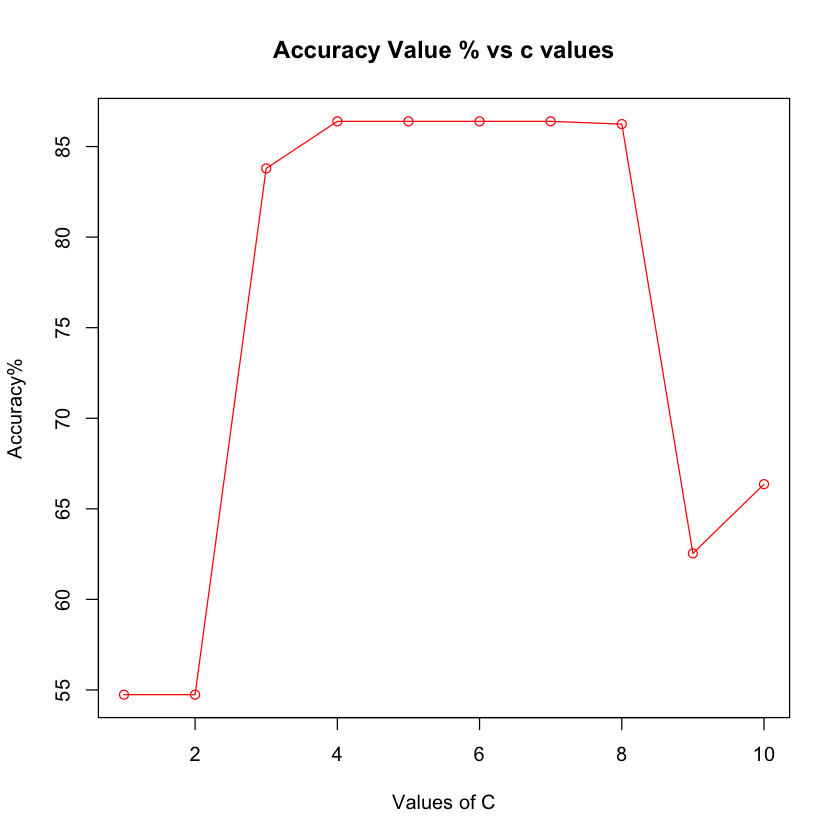

In [128]:
c_val = c(.00001,.0001,.001,.01,.1,1,100,10000,1000000,100000000)
c_labels <- c("1e-05","1e-04","1e-03","1e-02","1e-01","1e+00","1e+01","1e+02","1e+03","1e+04","1e+05","1e+06","1e+07","1e+08")
c_accurcy = c()

results <- data.frame("value of C" = integer(), matching = numeric(),n_trial=integer(), stringsAsFactors = FALSE)

for(i in c_val){
  
  # Set up SVM model
    model <- ksvm(
  as.matrix(Data_1[, 0:10]),        # Variables  used for classification
  as.factor(Data_1[, 11]),         # Target variable
  type   = "C-svc",
  kernel = "vanilladot",
  C      = i,
  scaled = TRUE
    )
  
  # Predict values
  pred<- predict(model,Data_1[,1:10])
  
  # Measure the accuracy
  
  confusion_matrix <- table(pred, Data_1[,11])
  
  #print(confusion_matrix)
  
  
  Accuracy_val <- (confusion_matrix[[4]] + confusion_matrix[[1]])/nrow(Data_1)
  
  print(paste("C value:", i, " - Accuracy:", Accuracy_val))

  results[nrow(results) + 1,] <- c(i,Accuracy_val*100,nrow(results) + 1) 
  results

}

c_accurcy

c_val

results


par(bg="white")

plot(y=results$matching ,x=results$n_trial, type = "o", col = "red", xlab = "Values of C", ylab = "Accuracy%",
     main = "Accuracy Value % vs c values", axes = TRUE)

`` The highest accuracy is achieved for intermediate values of C As C becomes either much smaller or much larger than this middle range, the accuracy decreases.``

#### 📌 Question 2.2.2
##### You are welcome, but not required, to try other (nonlinear) kernels as well; we’re not covering them in this course, but they can sometimes be useful and might provide better predictions than vanilladot.

 Setting default kernel parameters  
[1] "polydot"
[1] "C value: polydot  - Accuracy: 0.863914373088685"
[1] "rbfdot"
[1] "C value: rbfdot  - Accuracy: 0.952599388379205"
 Setting default kernel parameters  
[1] "tanhdot"
[1] "C value: tanhdot  - Accuracy: 0.7217125382263"
[1] "laplacedot"
[1] "C value: laplacedot  - Accuracy: 1"
 Setting default kernel parameters  
[1] "besseldot"
[1] "C value: besseldot  - Accuracy: 0.925076452599388"
 Setting default kernel parameters  
[1] "anovadot"
[1] "C value: anovadot  - Accuracy: 0.906727828746177"
 Setting default kernel parameters  
[1] "splinedot"
[1] "C value: splinedot  - Accuracy: 0.978593272171254"


,kernel_types,matching,n_trial
,<chr>,<chr>,<chr>
1,polydot,86.3914373088685,1
2,rbfdot,95.2599388379205,2
3,tanhdot,72.17125382263,3
4,laplacedot,100,4
5,besseldot,92.5076452599388,5
6,anovadot,90.6727828746177,6
7,splinedot,97.8593272171254,7


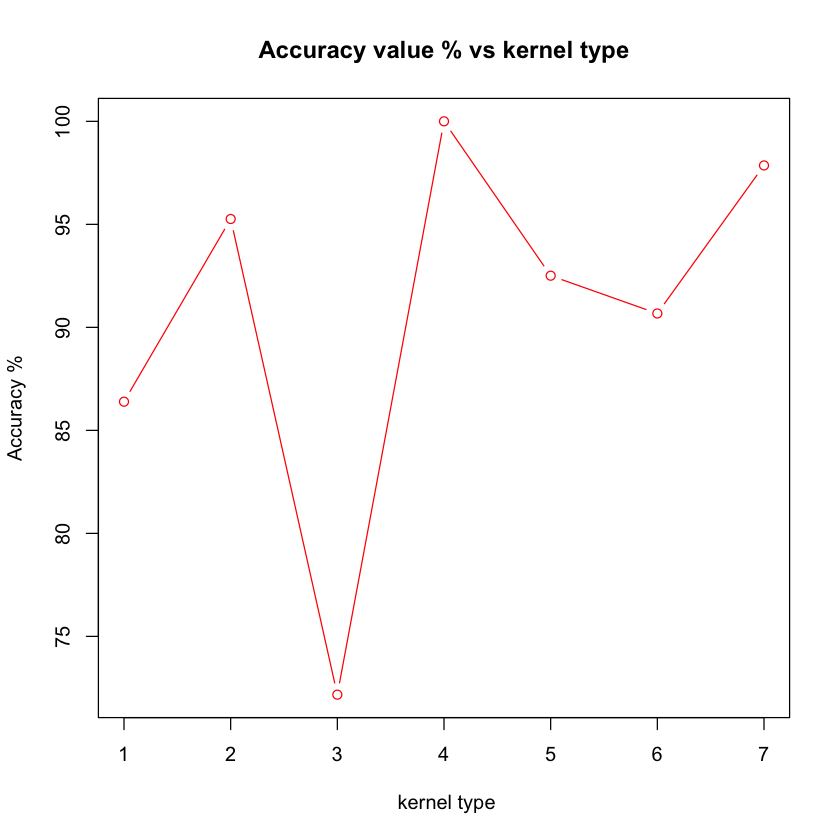

In [129]:
# Listing all different Kernels to iterate different and test the accuracy

kerneltypes<-c('polydot', 'rbfdot', 'tanhdot', 'laplacedot', 'besseldot', 'anovadot', 'splinedot')

results_kernel <- data.frame(kernel_types = character(), matching = numeric(),n_trial=integer(), stringsAsFactors = FALSE)

r<-1

for(i in kerneltypes){
  
  # Set up SVM model
    model <- ksvm(
  as.matrix(Data_1[, 0:10]),        # Variables  used for classification
  as.factor(Data_1[, 11]),         # Target variable
  type   = "C-svc",
  kernel = i,
  C      = 100,
  scaled = TRUE
    )
  print(i)
  # Predict values
  pred<- predict(model,Data_1[,1:10])
  
  # Measure the accuracy
  
  confusion_matrix <- table(pred, Data_1[,11])
  
  #print(confusion_matrix)
  
  
  Accuracy_val <- (confusion_matrix[[4]] + confusion_matrix[[1]])/nrow(Data_1)
  
  print(paste("C value:", i, " - Accuracy:", Accuracy_val))

  results_kernel[r,] <- c(i,Accuracy_val*100,r) 
  
r<-r+1
}

results_kernel

par(bg="white")

plot(y=results_kernel$matching,x=results_kernel$n_trial, type = "b", col = "red", xlab = " kernel type", ylab = "Accuracy %",
     main = "Accuracy value % vs kernel type", axes = TRUE)

#### 📌 Question 2.2.3
##### Using the k-nearest-neighbors classification function kknn contained in the R kknn package, suggest a good value of k, and show how well it classifies that data points in the full data set.  Don’t forget to scale the data (scale=TRUE in kknn).

In [130]:
# KNN model

library("kknn")

Data_1_kknn<-Data_1

# iterate different k values to find the best one

results_kknn <- data.frame(k = integer(), accuracy = numeric(), stringsAsFactors = FALSE)

j<-1
for(r in 1:20){
i <- sample(1:nrow(Data_1_kknn), nrow(Data_1_kknn)*0.7)


training_set <- Data_1_kknn[i, ]
test_set <- Data_1_kknn[-i, ]
model_kknn <- train.kknn(
    R1 ~ ., 
    data = training_set,
    kernel= "optimal",
    kmax = r,
    Scale = TRUE
)
pred <- predict(object = model_kknn, newdata = test_set)

confusion_matrix <- table(Actual = Data_1_kknn[1:length(pred),11], Predicted = pred)

# Calculate accuracy
accuracy <- sum(diag(confusion_matrix)) / sum(confusion_matrix)
#cat("\nModel Accuracy:", round(accuracy * 100, 2), "%\n")
results_kknn[j,] <- c(r,accuracy*100)
j<-j+1

}

results_kknn

,k,accuracy
,<dbl>,<dbl>
1,1,55.837563
2,2,22.335025
3,3,18.274112
4,4,16.751269
5,5,14.720812
6,6,13.197970
7,7,14.213198
8,8,17.258883
9,9,8.629442
